In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("car - prediction.csv")

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


### What this does

- frac=1 → take 100% of rows
- random_state=42 → reproducible shuffle
- reset_index(drop=True) → clean index

In [4]:
X = df.drop(columns=["selling_price"], axis=1)
X

,name,year,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,90000,Diesel,Individual,Manual,First Owner


In [5]:
y = df["selling_price"]
y

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 4340, dtype: int64

- **handle_unknown='ignore':** If the encoder sees a new category (e.g., a car brand not in the training set), it will simply represent it as all zeros in the one-hot encoded columns instead of crashing your app.

- **sparse_output=False:** (Optional but recommended for Streamlit) Returns a regular numpy array instead of a sparse matrix, which is easier to handle when passing data to the model for prediction.

In [6]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numerical_transfomer = StandardScaler()
hot_transfomer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer ([
    ("OneHotEncoder", hot_transfomer, cat_features),
    ("StandardScalar", numerical_transfomer, num_features)
])

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=2)

In [8]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [9]:
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted)
    r2_squared = r2_score(actual, predicted)
    return mae, rmse, r2_squared

In [10]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mae, train_mse, train_r2 = evaluate_model(Y_train, y_train_pred)
test_mae, test_mse, test_r2 = evaluate_model(Y_test, y_test_pred)

print("Linear Regression")
print(f"Training: mae: {train_mae} rmse: {train_mse} r2: {train_r2}")
print(f"Testing: mae: {test_mae} rmse: {test_mse} r2: {test_r2}")

Linear Regression
Training: mae: 40089.669930387005 rmse: 6340153822.45369 r2: 0.9811873639535998
Testing: mae: 102598.2580040441 rmse: 49072580691.454384 r2: 0.8489896117972926


In [12]:
score = r2_score(Y_test, y_test_pred)*100
print(f"Accuarcu r2 score: {score}")

Accuarcu r2 score: 84.89896117972926


Text(0, 0.5, 'Predicted')

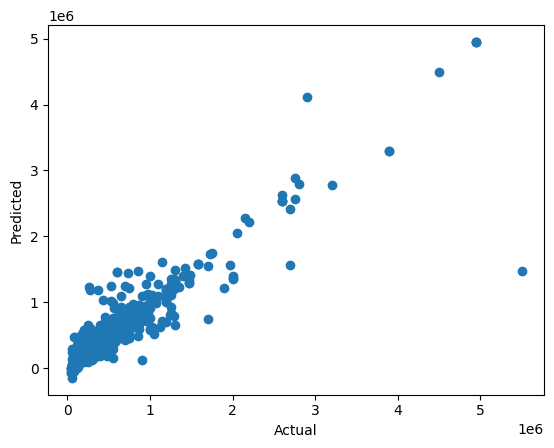

In [13]:
plt.scatter(Y_test, y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='selling_price'>

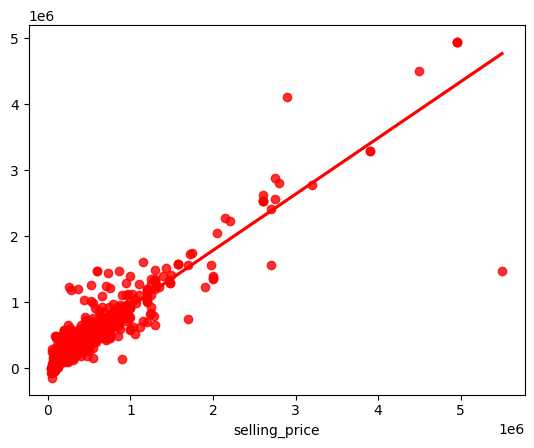

In [14]:
sns.regplot(x=Y_test, y=y_test_pred, ci=None, color="red")

In [15]:
pred_df = pd.DataFrame({"Actual":Y_test, "Predicted":y_test_pred, "Diffrence":Y_test-y_test_pred})
pred_df.to_csv("actual_vs_predicted.csv", index=False)
pred_df

,Actual,Predicted,Diffrence
1149,625000,8.579352e+05,-2.329352e+05
2245,520000,5.200000e+05,-3.958121e-09
4261,115999,1.159990e+05,-5.820766e-10
2865,2000000,1.366465e+06,6.335347e+05
3110,707000,7.145454e+05,-7.545432e+03
...,...,...,...
2168,100000,4.611362e+05,-3.611362e+05
3783,650000,9.227543e+05,-2.727543e+05
1683,430000,4.341147e+05,-4.114725e+03
2420,100000,3.099128e+05,-2.099128e+05


In [16]:
import joblib
joblib.dump(model, "model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']